<a href="https://colab.research.google.com/github/masterAristocats/Proc-Sin-Trabalho-Extra/blob/main/examples/beampattern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###SEÇÃO 5

In [1]:
!git clone https://github.com/masterAristocats/Proc-Sin-Trabalho-Extra.git

Cloning into 'Proc-Sin-Trabalho-Extra'...
remote: Enumerating objects: 158, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 158 (delta 73), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (158/158), 9.64 MiB | 7.83 MiB/s, done.
Resolving deltas: 100% (73/73), done.


In [2]:
%cd Proc-Sin-Trabalho-Extra

!ls src

/content/Proc-Sin-Trabalho-Extra
beampattern.py	 generate_ucya.py  generate_upa.py
generate_uca.py  generate_ula.py   steering_vector.py


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from src.generate_ula import generate_ula
from src.generate_uca import generate_uca
from src.generate_upa import generate_upa
from src.generate_ucya import generate_ucya
from src.steering_vector import steering_vector

from src.beampattern import beampattern

##Definir parâmetros

In [4]:
wavelength = 1.0

###ULA (M = 9)

In [5]:
M = 9
d = wavelength / 2

positions = generate_ula(M, d)

theta = np.linspace(-90, 90, 721)
theta_rad = np.deg2rad(theta)

gain = beampattern(
    positions,
    azimuth=0,
    elevation=theta_rad,
    wavelength=wavelength
)

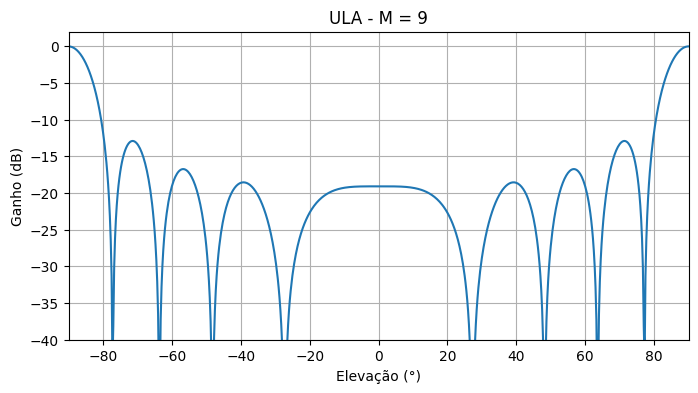

In [6]:
plt.figure(figsize=(8,4))

plt.plot(theta, gain)

plt.title("ULA - M = 9")

plt.xlabel("Elevação (°)")
plt.ylabel("Ganho (dB)")

plt.grid(True)

plt.xlim(-90,90)
plt.ylim(-40,2)

plt.show()

##ULA (M = 16)

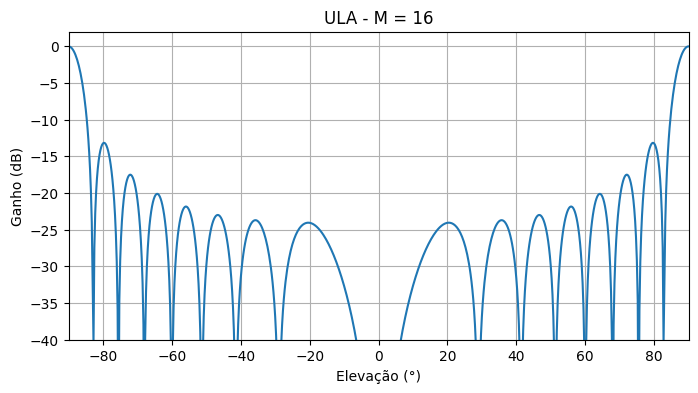

In [7]:
M = 16

positions = generate_ula(M, d)

gain = beampattern(
    positions,
    azimuth=0,
    elevation=theta_rad,
    wavelength=wavelength
)

plt.figure(figsize=(8,4))
plt.plot(theta, gain)
plt.grid(True)

plt.title("ULA - M = 16")
plt.xlabel("Elevação (°)")
plt.ylabel("Ganho (dB)")

plt.xlim(-90,90)
plt.ylim(-40,2)

plt.show()

##UCA (M=9)

In [8]:
phi = np.linspace(0,360,721)

phi_rad = np.deg2rad(phi)

In [9]:
positions = generate_uca(
    M=9,
    R=wavelength
)

gain = beampattern(
    positions,
    azimuth=phi_rad,
    elevation=0,
    wavelength=wavelength
)

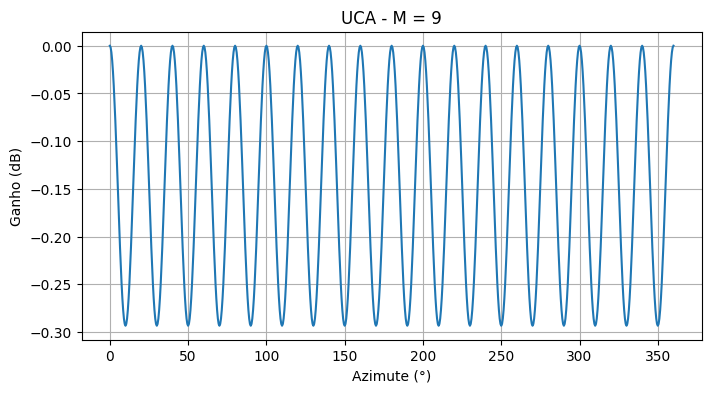

In [10]:
plt.figure(figsize=(8,4))

plt.plot(phi, gain)

plt.grid(True)

plt.title("UCA - M = 9")

plt.xlabel("Azimute (°)")
plt.ylabel("Ganho (dB)")

plt.show()

##UCA (M=16)

In [11]:
phi = np.linspace(0,360,721)

phi_rad = np.deg2rad(phi)

In [12]:
positions = generate_uca(
    M=16,
    R=wavelength
)

gain = beampattern(
    positions,
    azimuth=phi_rad,
    elevation=0,
    wavelength=wavelength
)

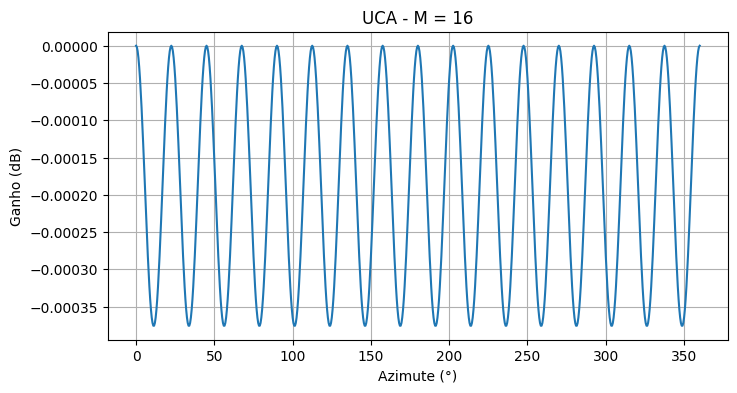

In [14]:
plt.figure(figsize=(8,4))

plt.plot(phi, gain)

plt.grid(True)

plt.title("UCA - M = 16")

plt.xlabel("Azimute (°)")
plt.ylabel("Ganho (dB)")

plt.show()

##UPA (M=3, 4)

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from src.generate_upa import generate_upa
from src.steering_vector import steering_vector

In [29]:
wavelength = 1.0

dx = wavelength / 2
dy = wavelength / 2

# Valores de M exigidos
M_values = [3, 4]

In [30]:
#Definir a malha de ângulos

phi = np.linspace(-90, 90, 181)
theta = np.linspace(-90, 90, 181)

PHI, THETA = np.meshgrid(phi, theta)

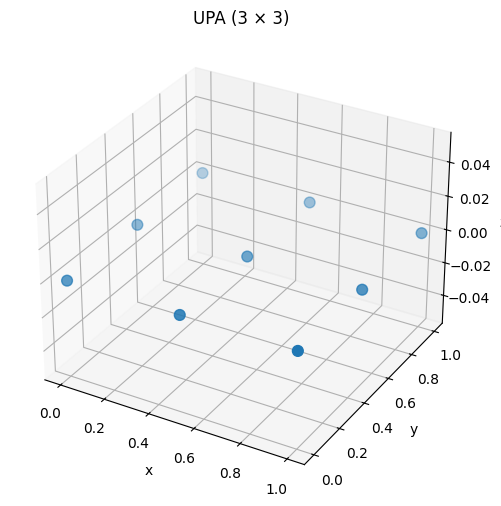

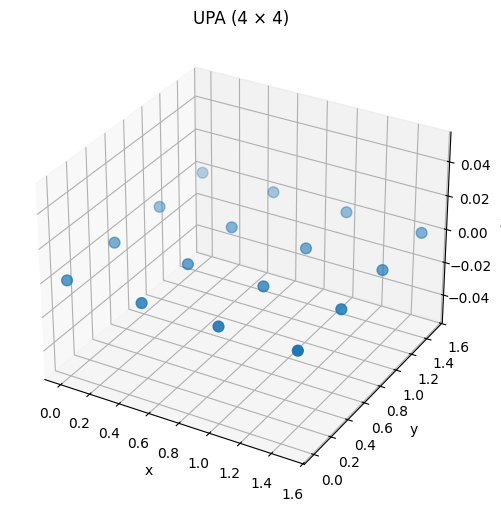

In [31]:
#Gerar o arranjo e mostrar a geometria

for M in M_values:

    positions = generate_upa(
        M,
        M,
        dx,
        dy
    )

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        positions[:, 0],
        positions[:, 1],
        positions[:, 2],
        s=60
    )

    ax.set_title(f"UPA ({M} × {M})")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    plt.show()

In [32]:
#Calcular o Beampattern

for M in M_values:

    positions = generate_upa(
        M,
        M,
        dx,
        dy
    )

    weights = np.ones(len(positions), dtype=complex)

    gain = np.zeros(PHI.shape)

    for i in range(PHI.shape[0]):
        for j in range(PHI.shape[1]):

            a = steering_vector(
                positions,
                np.deg2rad(PHI[i, j]),
                np.deg2rad(THETA[i, j]),
                wavelength
            )

            gain[i, j] = np.abs(
                np.conjugate(weights) @ a
            )

    gain /= np.max(gain)

    gain_db = 20 * np.log10(
        np.maximum(gain, 1e-12)
    )

    globals()[f"gain_db_{M}"] = gain_db

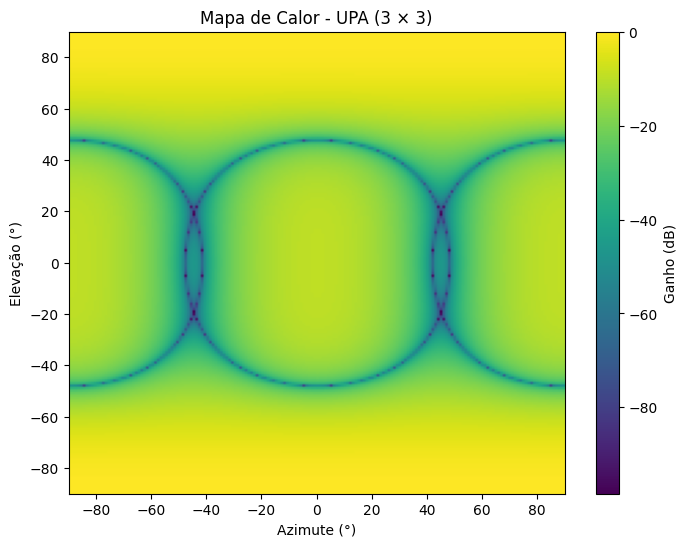

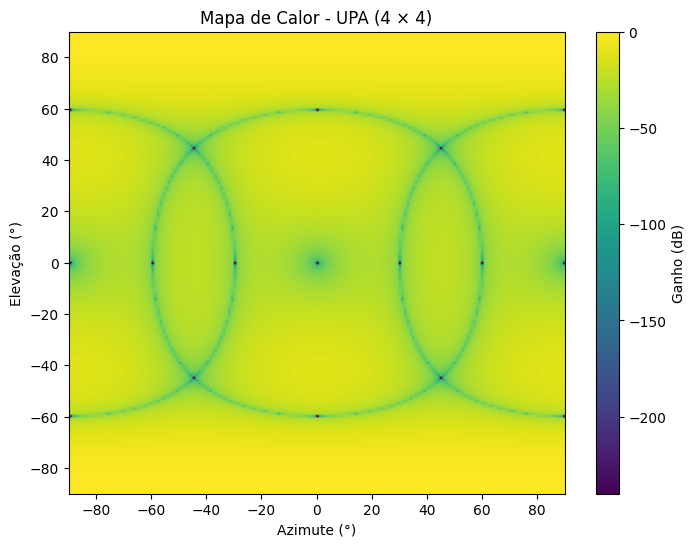

In [33]:
#Heatmap

for M in M_values:

    gain_db = globals()[f"gain_db_{M}"]

    plt.figure(figsize=(8, 6))

    plt.imshow(
        gain_db,
        extent=[-90, 90, -90, 90],
        origin="lower",
        aspect="auto"
    )

    plt.colorbar(label="Ganho (dB)")

    plt.xlabel("Azimute (°)")
    plt.ylabel("Elevação (°)")

    plt.title(f"Mapa de Calor - UPA ({M} × {M})")

    plt.show()

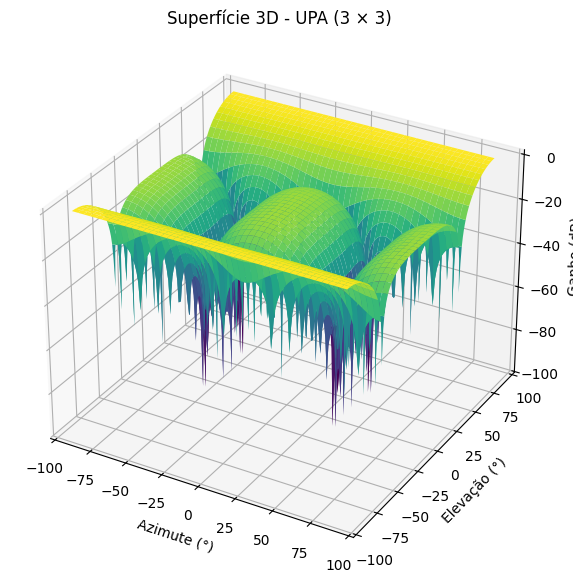

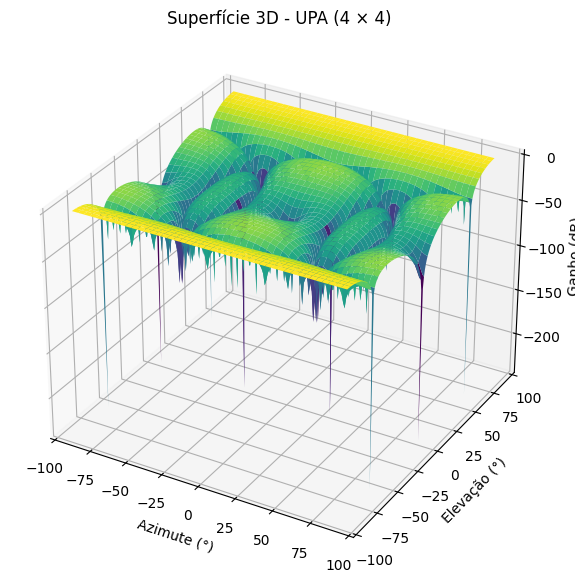

In [34]:
#Superfície 3D

for M in M_values:

    gain_db = globals()[f"gain_db_{M}"]

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        PHI,
        THETA,
        gain_db,
        cmap="viridis"
    )

    ax.set_title(f"Superfície 3D - UPA ({M} × {M})")

    ax.set_xlabel("Azimute (°)")
    ax.set_ylabel("Elevação (°)")
    ax.set_zlabel("Ganho (dB)")

    plt.show()

##UCYA (M=9, 16) (N=4, 6)

In [38]:
wavelength = 1.0

R = wavelength
dz = wavelength / 2

Mc_values = [9, 16]
Nz_values = [4, 6]

In [39]:
#Malha dos ângulos

phi = np.linspace(-180, 180, 361)
theta = np.linspace(-90, 90, 181)

PHI, THETA = np.meshgrid(phi, theta)

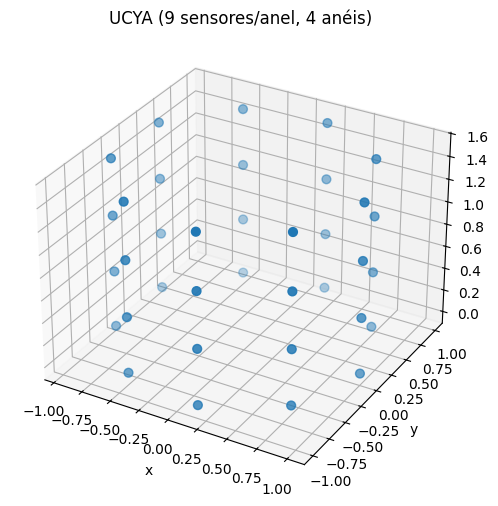

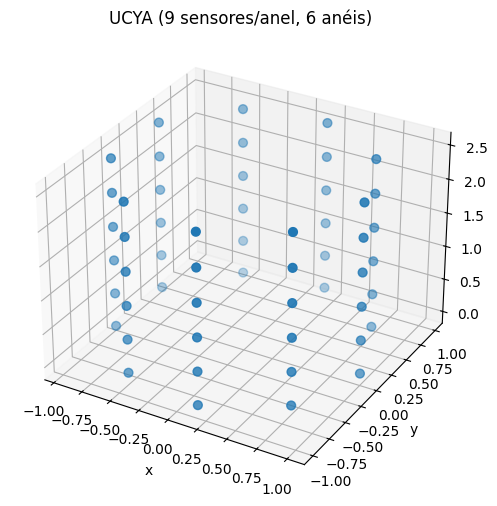

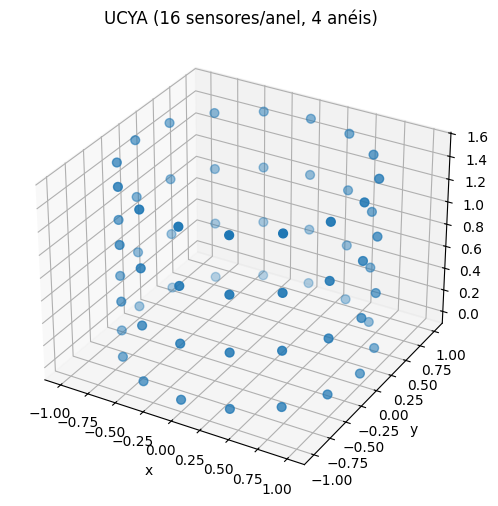

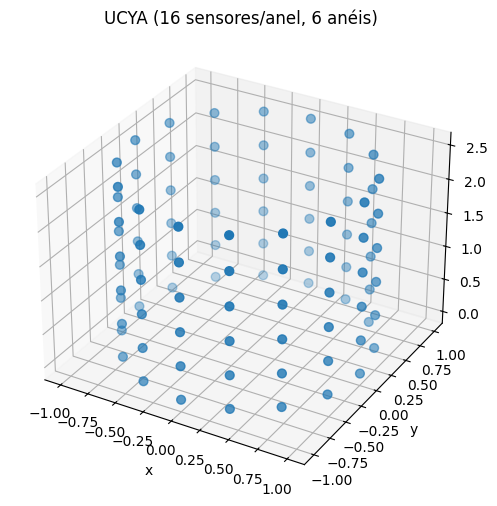

In [40]:
#visualização 3D

for Mc in Mc_values:
    for Nz in Nz_values:

        positions = generate_ucya(
            Mc,
            Nz,
            R,
            dz
        )

        fig = plt.figure(figsize=(6,6))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            positions[:,0],
            positions[:,1],
            positions[:,2],
            s=40
        )

        ax.set_title(f"UCYA ({Mc} sensores/anel, {Nz} anéis)")

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")

        plt.show()

In [41]:
#Cálculo do ganho

for Mc in Mc_values:
    for Nz in Nz_values:

        positions = generate_ucya(
            Mc,
            Nz,
            R,
            dz
        )

        weights = np.ones(len(positions), dtype=complex)

        gain = np.zeros(PHI.shape)

        for i in range(PHI.shape[0]):
            for j in range(PHI.shape[1]):

                a = steering_vector(
                    positions,
                    np.deg2rad(PHI[i, j]),
                    np.deg2rad(THETA[i, j]),
                    wavelength
                )

                gain[i, j] = np.abs(
                    np.conjugate(weights) @ a
                )

        gain /= np.max(gain)

        gain_db = 20*np.log10(
            np.maximum(gain,1e-12)
        )

        globals()[f"gain_{Mc}_{Nz}"] = gain_db

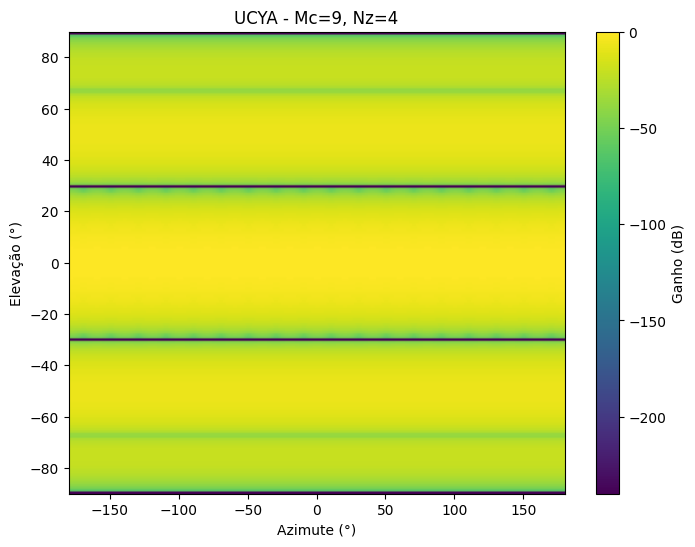

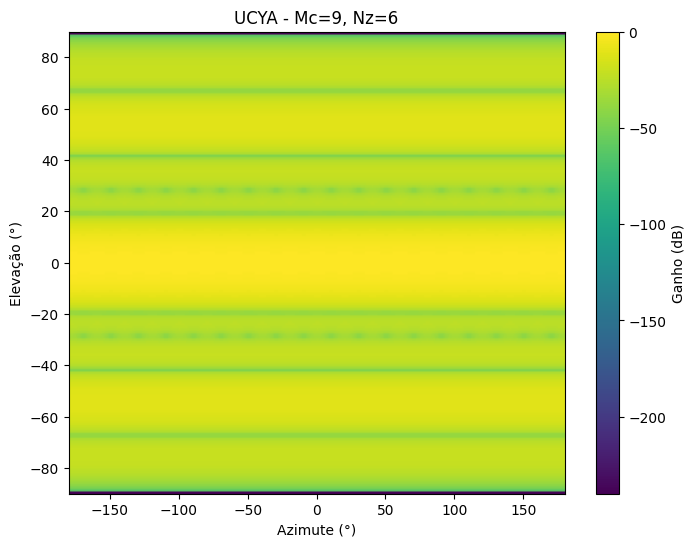

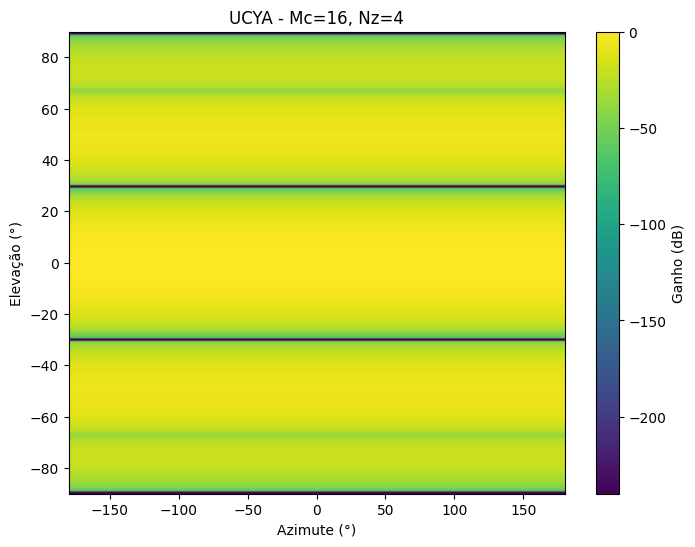

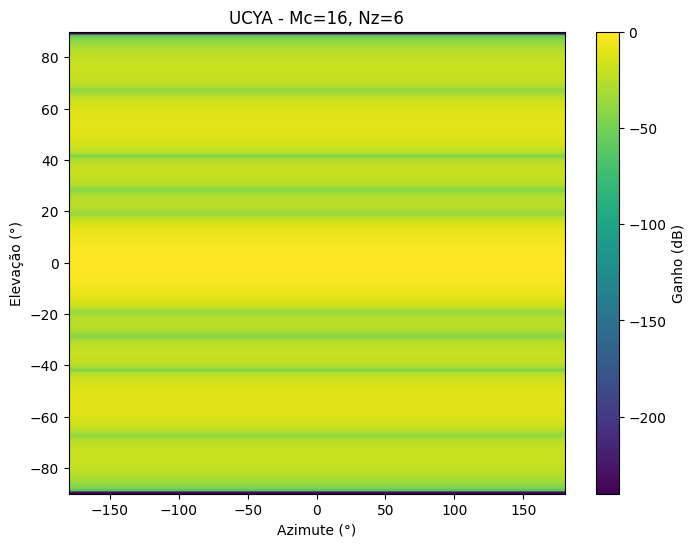

In [42]:
#Mapa bidimensional

for Mc in Mc_values:
    for Nz in Nz_values:

        gain_db = globals()[f"gain_{Mc}_{Nz}"]

        plt.figure(figsize=(8,6))

        plt.imshow(
            gain_db,
            extent=[-180,180,-90,90],
            origin="lower",
            aspect="auto"
        )

        plt.colorbar(label="Ganho (dB)")

        plt.xlabel("Azimute (°)")
        plt.ylabel("Elevação (°)")

        plt.title(
            f"UCYA - Mc={Mc}, Nz={Nz}"
        )

        plt.show()